## Executive Summary

This notebook explores the modeling of daily stock excess growth rates using Hidden Markov Models (HMMs). The analysis proceeds in three main stages:
1.  A standard HMM is built from historical in-sample data.
2.  This model is then tested against well-known "stylized facts" of financial returns, revealing its strengths (capturing return distributions) and weaknesses (failing to capture volatility clustering).
3.  To address these weaknesses, a modified HMM that incorporates price jumps is introduced and analyzed, demonstrating its improved ability to replicate the observed market dynamics.

 # Build a Hidden Markov Model of Daily Stock Excess Growth Rate
We are constructing an Observable Markov Model (OMM) of the excess growth rate of a ticker `XYZ` where we define the excess growth as:
$$
\begin{equation*}
R_{ij} \equiv \left(\frac{1}{\Delta{t}}\right)\cdot\ln\left(\frac{S_{i,j}}{S_{i,j-1}}\right) - \bar{r}_{f}
\end{equation*}
$$
where $R_{ij}$ denotes the excess growth rate of equity $i$ at time $j$, $\Delta{t}$ denotes the time-step between $j-1\rightarrow{j}$ (units: years), $S_{i,\star}$ denotes the share price of equity $i$ at time $\star$, and $\bar{r}_{f}$ denotes the annualized risk free rate. In this work, we build a model of daily return.

## Model
Describe the day-to-day variation of the excess growth using a fully observable Markov model $\mathcal{M}$ represented by the tuple $\mathcal{M} = (\mathcal{S},\mathcal{O},\mathbf{P},\mathbf{E})$; $\mathcal{S}$ is the set of hidden states, $\mathcal{O}$ is the set of observable states, $\mathbf{T}$ is the transition matrix, i.e., $t_{ij}\in\mathbf{T}$ is the probability of moving from hidden state $i$ to hidden state $j$ in the next time step, and $\mathbf{E}$ is the emission matrix. Because we are fully observable, the emission matrix $\mathbf{E} = \mathbf{I}$, where $\mathbf{I}$ is the identity matrix.

## Objectives
- **Task 1:** Characterize the continuous distribution of returns using MLE and MCMC, then discretize this distribution to build a Hidden Markov Model (HMM).
- **Task 2:** Simulate the standard HMM and analyze its ability to reproduce key stylized facts of financial returns, particularly volatility clustering.
- **Task 3:** Introduce and analyze an HMM with jumps to see if it improves upon the standard model's weaknesses.
- **Task 4:** Save the final model artifacts for future use.

## Setup
We set up the computational environment by including the `Include.jl` file. The `Include.jl` file loads external packages, various functions that we will use in the exercise, and custom types to model the components of our lab problem.
* For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [VLQuantitativeFinancePackage.jl documentation](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl).

In [1]:
include("Include.jl");

    Updating git-repo `https://github.com/varnerlab/VLQuantitativeFinancePackage.jl.git`
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed JpegTurbo_jll ──────────── v3.1.4+0
   Installed SciMLLogging ───────────── v1.7.1
   Installed Optimisers ─────────────── v0.4.7
   Installed RecursiveArrayTools ────── v3.41.0
   Installed SolverCore ─────────────── v0.3.9
   Installed AdvancedPS ─────────────── v0.7.2
   Installed Preferences ────────────── v1.5.1
   Installed Turing ─────────────────── v0.42.0
   Installed NearestNeighbors ───────── v0.4.26
   Installed MappedArrays ───────────── v0.4.3
   Installed Bijectors ──────────────── v0.15.14
   Installed SciMLBase ──────────────── v2.128.0
   Installed MathOptInterface ───────── v1.48.0
   Installed GLFW_jll ───────────────── v3.4.1+0
   Installed ProgressLogging ────────── v0.1.6
   Installed SciMLOperators ─────────── v1.14.1
   Installed libpng_jll ─────────────── v1.6.53+0
   

## Setting Up Constants

In [2]:
risk_free_rate = 0.0421; # 17-Jun-2024 10-year treasury
Δt = (1/252); # time step 1 x trading in units of years
number_of_paths = 1000; # number of potential futures should we look at
ticker = "SPY"; # This is the ticker we want to explore

## Prerequisites: Load and clean the historical dataset
We gathered a daily open-high-low-close `dataset` for each firm in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `02-07-2025`, along with data for a few exchange-traded funds and volatility products during that time. In this block of code, we:
* Load and clean the historical data; store the cleaned data in the `dataset` variable. We then calculate the expected excess return $\mathbb{E}(R_{i})$ for each `ticker` in the `dataset.` Finally, you'll select a firm by changing the value in the `ticker` variable. We store the computed excess return for the `ticker` in the `Rᵢ` variable.

### Load the training data

The dataset for this analysis consists of daily open-high-low-close (OHLC) data for firms in the S&P 500, spanning from **January 3, 2014, to February 7, 2025**. This data was cleaned and split into training and testing sets in a separate preprocessing step.

We begin by loading the pre-cleaned **training dataset** below.

In [3]:
train_dataset = MyPortfolioDataSet() |> x->x["dataset"]

Dict{String, DataFrame} with 515 entries:
  "DD"   => 2329×8 DataFrame…
  "EMR"  => 2767×8 DataFrame…
  "CTAS" => 2767×8 DataFrame…
  "HSIC" => 2767×8 DataFrame…
  "KIM"  => 2767×8 DataFrame…
  "PLD"  => 2767×8 DataFrame…
  "IEX"  => 2767×8 DataFrame…
  "TPR"  => 1803×8 DataFrame…
  "BAC"  => 2767×8 DataFrame…
  "CBOE" => 2767×8 DataFrame…
  "EXR"  => 2767×8 DataFrame…
  "NCLH" => 2767×8 DataFrame…
  "CVS"  => 2767×8 DataFrame…
  "DRI"  => 2767×8 DataFrame…
  "DTE"  => 2767×8 DataFrame…
  "ZION" => 2767×8 DataFrame…
  "AVY"  => 2767×8 DataFrame…
  "EW"   => 2767×8 DataFrame…
  "EA"   => 2767×8 DataFrame…
  "NWSA" => 2767×8 DataFrame…
  "BBWI" => 859×8 DataFrame…
  "CAG"  => 2767×8 DataFrame…
  "GPC"  => 2767×8 DataFrame…
  "FCX"  => 2767×8 DataFrame…
  "GILD" => 2767×8 DataFrame…
  ⋮      => ⋮

In [4]:
train_dataset["AAPL"]

Row,volume,volume_weighted_average_price,open,close,high,low,timestamp,number_of_transactions
,Float64,Float64,Float64,Float64,Float64,Float64,DateTime,Int64
1,3.93215e8,19.4749,19.745,19.3207,19.775,19.3011,2014-01-03T05:00:00,148584
2,4.13437e8,19.3213,19.1946,19.4261,19.5286,19.0571,2014-01-06T05:00:00,131664
3,3.17731e8,19.3329,19.44,19.2871,19.4986,19.2116,2014-01-07T05:00:00,107327
4,2.58747e8,19.4038,19.2432,19.4093,19.4843,19.2389,2014-01-08T05:00:00,86874
5,2.79621e8,19.2943,19.5286,19.1614,19.5307,19.1196,2014-01-09T05:00:00,93562
6,3.05283e8,19.0659,19.2796,19.0336,19.3143,18.9682,2014-01-10T05:00:00,113063
7,3.79443e8,19.1801,18.9254,19.1332,19.375,18.9243,2014-01-13T05:00:00,130227
8,3.34937e8,19.4033,19.2221,19.5139,19.5261,19.2021,2014-01-14T05:00:00,114856
9,3.9389e8,19.9105,19.7686,19.9057,20.0071,19.7021,2014-01-15T05:00:00,136942


In [5]:
maximum_number_trading_days = nrow(train_dataset["AAPL"])

2767

In [6]:
dataset = Dict{String,DataFrame}();
for (ticker,data) ∈ train_dataset
    if (nrow(data) == maximum_number_trading_days)
        dataset[ticker] = data;
    end
end

Lastly, let's get a sorted list of firms that we have in cleaned up `dataset` and save it in the `list_of_all_tickers::Array{String,1}` array

In [7]:
list_of_all_tickers = keys(dataset) |> collect |> x->sort(x)

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 "ADP"
 "ADSK"
 "AEE"
 ⋮
 "WST"
 "WU"
 "WY"
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

We compute the expected (annualized) log growth rate by passing the `dataset` and the entire list of firms we have in the dataset (held in the $N\times{1}$ `list_of_all_tickers` array) to the [log_growth_matrix(...) method](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix).
* The result is stored in the `all_firms_return_matrix::Array{Float64,2}` variable, a $T-1\times{N}$ array of log return values. Each row of `all_firms_return_matrix` corresponds to a time value, while each column corresponds to a firm:

In [8]:
all_firms_excess_return_matrix = log_growth_matrix(dataset, list_of_all_tickers,
    Δt = Δt, risk_free_rate = risk_free_rate)

2766×424 Matrix{Float64}:
 -0.919654    6.23895    -2.91307    …  -0.797491   0.203794  -1.04737
  2.77416     1.02939     1.35029        2.09622   -0.84489    0.944368
  3.27095     0.813497   -0.036732       0.067777   1.1489    -2.62354
  0.604325   17.2178      1.65005        0.232616   3.1172    -0.410328
  1.77399     2.53751     3.27714        0.579577  -2.2108     4.36099
  0.57173    -4.00594    -0.83488    …  -0.904839  -1.95187   -3.15834
  2.81861    -0.525851    4.80363        1.7236    -1.81895   -1.1317
  2.00461     0.971404    1.86599        1.63387    4.40774   -0.179919
  1.27079     1.63203     0.0651592     -1.54918   -2.17906    1.39574
  1.17806     6.08747     0.890478      -1.57412    2.83574   -1.47836
 -0.479768    4.82799     0.96564    …  -0.363361   9.46617   -3.05083
  1.32071     3.57107    -2.38986        0.668513   4.48013    0.298431
 -4.78114     1.34375    -3.05834       -2.19455   -6.69117    1.36402
  ⋮                                  ⋱          

Extract the growth rate for your `ticker::String` of interest, and save this in the `Rᵢ::Array{Float64,1}` array. This is the observed _in-sample_ data.

In [9]:
Rᵢ = findfirst(x->x==ticker, list_of_all_tickers) |> i-> all_firms_excess_return_matrix[:,i]

2766-element Vector{Float64}:
 -0.6266399670984476
  0.8405262386945092
  0.16389199696256232
 -0.010233691939436122
  0.25823420862761537
 -1.378088774125505
  0.32241271641711466
  2.0009590819913137
 -0.322149763808254
 -0.43598073791618397
 -0.07579593758943923
  0.3992882778085264
 -1.99925091651247
  ⋮
 -0.5428518800661111
  0.9030508357217608
 -1.0139344267279928
 -3.818285890907456
 -3.0867707822786663
  0.23453278078089898
  1.6089264971962087
  2.689709238274075
  0.7453999191864145
 -2.7609744641560034
 -2.504601843730946
 -0.9624409493684527

## Task 1: Characterizing and Discretizing the Return Distribution
### Methodology: Building the Model from Data

To construct the HMM, we first need to define its components from the historical returns data (`Rᵢ`):

1.  **States:** The continuous range of daily returns is discretized into a finite number of states. Each state represents a specific market condition, from significant losses (State 1) to significant gains (State N). We define these states by calculating the quantiles of the historical return distribution.

2.  **Transition Matrix:** The probability of moving from one state to another on the next day is estimated by observing the frequency of these transitions in the historical data.

3.  **Emission Probabilities:** In this model, the emissions are deterministic. Being in a certain state means the return is within the predefined quantile range for that state.

First, consider the states $\mathcal{S}$. Suppose we number the excess return values, ranging from `super bad = 1,` $\dots$,` unchanged,` $\dots$,` super good = N,` where if $R\ll{0}$, then we are in the `super bad = 1,` state or $R\gg{0}$ we are in the `super good = N` state (or we are someplace in between).
* __Idea__: Use the [cumulative distribution function](https://en.wikipedia.org/wiki/Cumulative_distribution_function) computed from the observed return series $R_{i,1}, \dots, R_{i,n}$ to partition the actual (historical) excess returns into one of a fixed number of categories. Once we have the categories, compute the probability that category $i$ on the day $k$ is followed by category $j$ on the day $k+1$. These values are entries in the state transition matrix $\hat{\mathbf{T}}$.
* To start, specify a value for the  `number_of_states` variable, where the `number_of_states` controls how many categories we are using when splitting up the excess return time series. We then set the `states` vector, which holds the states (numbered from `1`$\rightarrow$`number_of_states`).

In [10]:
number_of_states = 20; # specify a value here, too many states or too little states would impact the model performance. 100 should provide somewhat fair granuality 
states = range(1,stop=number_of_states) |> collect;

The `states` are hidden from the observer. Next, we set up the emissions matrix $\mathbf{E}$. For this example, because the states are __fully observable__, i.e., we can see the states directly,  the emission matrix $\mathbf{E}$ is the identity matrix $\mathbf{I}$:

In [11]:
E = diagm(ones(number_of_states))

20×20 Matrix{Float64}:
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

### Estimate the transition matrix $\hat{\mathbf{T}}$ from market data
To estimate the transition matrix $\hat{\mathbf{T}}$, we'll estimate the transition probabilities from the excess return data calculated in the `Prerequisites` section and saved in the `Rᵢ` variable.

In [12]:
in_sample_dataset = Rᵢ[1:(maximum_number_trading_days-1)] # set of excess return

2766-element Vector{Float64}:
 -0.6266399670984476
  0.8405262386945092
  0.16389199696256232
 -0.010233691939436122
  0.25823420862761537
 -1.378088774125505
  0.32241271641711466
  2.0009590819913137
 -0.322149763808254
 -0.43598073791618397
 -0.07579593758943923
  0.3992882778085264
 -1.99925091651247
  ⋮
 -0.5428518800661111
  0.9030508357217608
 -1.0139344267279928
 -3.818285890907456
 -3.0867707822786663
  0.23453278078089898
  1.6089264971962087
  2.689709238274075
  0.7453999191864145
 -2.7609744641560034
 -2.504601843730946
 -0.9624409493684527

### 1a. Analyzing the Underlying Continuous Distribution

Before building our discrete-state HMM, we first seek to understand the underlying continuous probability distribution of the daily excess returns. A key part of modeling is choosing a distribution that accurately captures the stylized facts of the data, such as **"fat tails"** (a higher probability of extreme events than a normal distribution would suggest).

In this section, we will:
1.  Compare two candidate distributions: the **Laplace distribution** and the **Student's t-distribution**.
2.  Compare two different methodologies for fitting these distributions: **Maximum Likelihood Estimation (MLE)** and the more robust **Markov Chain Monte Carlo (MCMC)**.

First, we use our generic MCMC function to fit a **Student's t-distribution** to the return data. This is our primary candidate for a model that can capture fat tails. The output will be a `chain` object containing the full posterior distributions for the model's parameters: mean (`μ`), volatility (`σ`), and degrees-of-freedom (`ν`).

In [13]:
# To learn the Student's t-distribution:
chain_t = learn_distribution_mcmc(StudentTModel(), Rᵢ);

# You can now analyze chain_t and chain_laplace as before
plot(chain_t)


LoadError: UndefVarError: `sample` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.
Hint: a global variable of this name also exists in StatsBase.
    - Also exported by Distributions.
    - Also exported by Clustering (loaded but not imported in Main).
    - Also exported by Bijectors (loaded but not imported in Main).
    - Also exported by AbstractMCMC (loaded but not imported in Main).
    - Also exported by MCMCChains.
    - Also exported by AdvancedHMC (loaded but not imported in Main).
    - Also exported by AdvancedMH (loaded but not imported in Main).
    - Also exported by SSMProblems (loaded but not imported in Main).
    - Also exported by EllipticalSliceSampling (loaded but not imported in Main).
    - Also exported by Turing.
Hint: a global variable of this name also exists in VLQua

Next, for a direct comparison, we fit the **Laplace distribution** using the same MCMC methodology. This will produce a `chain` object containing posteriors for the Laplace parameters: mean (`μ`) and scale (`b`).

In [14]:
# To learn the Laplace distribution:
chain_laplace = learn_distribution_mcmc(LaplaceModel(), Rᵢ);

plot(chain_laplace)


LoadError: UndefVarError: `sample` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.
Hint: a global variable of this name also exists in StatsBase.
    - Also exported by Distributions.
    - Also exported by Clustering (loaded but not imported in Main).
    - Also exported by Bijectors (loaded but not imported in Main).
    - Also exported by AbstractMCMC (loaded but not imported in Main).
    - Also exported by MCMCChains.
    - Also exported by AdvancedHMC (loaded but not imported in Main).
    - Also exported by AdvancedMH (loaded but not imported in Main).
    - Also exported by SSMProblems (loaded but not imported in Main).
    - Also exported by EllipticalSliceSampling (loaded but not imported in Main).
    - Also exported by Turing.
Hint: a global variable of this name also exists in VLQua

Finally, we will prepare all of our fitted models for a head-to-head comparison. We will use the traditional **Maximum Likelihood Estimation (MLE)** to fit a Laplace distribution as a baseline. Then, we will bring together all the models—both MCMC and MLE—for a final comparison using visual plots and quantitative statistics.

In [15]:
# --- Prepare All Four Models ---

# 1. MLE Model
Laplace_MLE = fit_mle(Laplace, Rᵢ);

# 2. MCMC Models 
μ_t_mean = mean(chain_t[:μ])
σ_t_mean = mean(chain_t[:σ])
ν_t_mean = mean(chain_t[:ν])
StudentT_MCMC = LocationScale(μ_t_mean, σ_t_mean, TDist(ν_t_mean))

μ_laplace_mean = mean(chain_laplace[:μ])
b_laplace_mean = mean(chain_laplace[:b])
Laplace_MCMC = Laplace(μ_laplace_mean, b_laplace_mean);


LoadError: UndefVarError: `chain_t` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

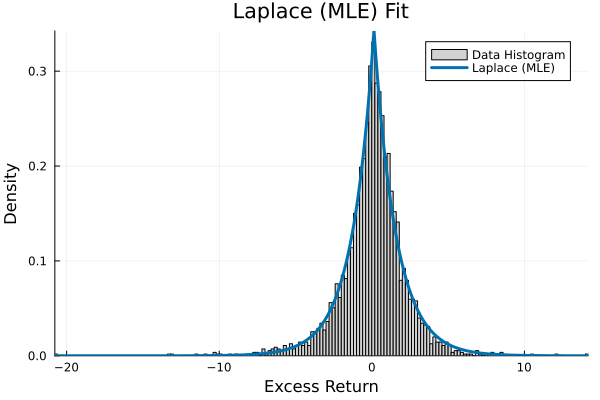

In [16]:
# --- Plot 1: Laplace (MLE) vs. Data ---

# Create a histogram of the actual returns data
histogram(Rᵢ, normalize=:pdf, bins=200, label="Data Histogram", c=:lightgray)

# Plot the Laplace (MLE) distribution
plot!(x -> pdf(Laplace_MLE, x), lw=3, label="Laplace (MLE)", c="#0072B2") # Blue

title!("Laplace (MLE) Fit")
xlabel!("Excess Return")
ylabel!("Density")
xlims!(extrema(Rᵢ))

In [17]:
# --- Plot 3: Laplace (MCMC) vs. Data ---

# Create a histogram of the actual returns data
histogram(Rᵢ, normalize=:pdf, bins=200, label="Data Histogram", c=:lightgray)

# Plot the Laplace (MCMC) distribution
plot!(x -> pdf(Laplace_MCMC, x), lw=3, label="Laplace (MCMC)", c="#009E73") # Bluish Green

title!("Laplace (MCMC) Fit")
xlabel!("Excess Return")
ylabel!("Density")
xlims!(extrema(Rᵢ))

LoadError: UndefVarError: `Laplace_MCMC` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [18]:
# --- Plot 2: Student's t (MCMC) vs. Data ---

# Create a histogram of the actual returns data
histogram(Rᵢ, normalize=:pdf, bins=200, label="Data Histogram", c=:lightgray)

# Plot the Student's t (MCMC) distribution
plot!(x -> pdf(StudentT_MCMC, x), lw=3, label="Student's t (MCMC)", c="#D55E00") # Vermillion/Orange

title!("Student's t (MCMC) Fit")
xlabel!("Excess Return")
ylabel!("Density")
xlims!(extrema(Rᵢ))

LoadError: UndefVarError: `StudentT_MCMC` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [19]:
# ---  Visual Comparison of Four Distributions ---

# Create a histogram of the actual returns data
histogram(Rᵢ, normalize=:pdf, bins=200, label="Data Histogram", c=:lightgray)

# Plot the four models
plot!(x -> pdf(Laplace_MLE, x), lw=3, label="Laplace (MLE)")
plot!(x -> pdf(StudentT_MCMC, x), lw=3, label="Student's t (MCMC)", ls=:dash)
plot!(x -> pdf(Laplace_MCMC, x), lw=3, label="Laplace (MCMC)", ls=:dot)

title!("Comparison of Fitted Distributions")
xlabel!("Excess Return")
ylabel!("Density")
xlims!(extrema(Rᵢ))

LoadError: UndefVarError: `StudentT_MCMC` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [20]:
# --- UPDATED: Quantitative Comparison of Four Distributions ---

# A. Summary Statistics
println("--- Summary Statistics ---")
println("Laplace (MLE):")
println("  Mean:      ", mean(Laplace_MLE))
println("  Variance:  ", var(Laplace_MLE))
println("  Kurtosis:  ", kurtosis(Laplace_MLE))

println("\nStudent's t (MCMC):")
println("  Mean:      ", mean(StudentT_MCMC))
println("  Variance:  ", var(StudentT_MCMC))
println("  Kurtosis:  ", kurtosis(StudentT_MCMC))

println("\nLaplace (MCMC):")
println("  Mean:      ", mean(Laplace_MCMC))
println("  Variance:  ", var(Laplace_MCMC))
println("  Kurtosis:  ", kurtosis(Laplace_MCMC))


# B. AIC Comparison (Lower is Better)
log_like_L_MLE = loglikelihood(Laplace_MLE, Rᵢ)
log_like_T_MCMC = loglikelihood(StudentT_MCMC, Rᵢ)
log_like_L_MCMC = loglikelihood(Laplace_MCMC, Rᵢ)

aic_L_MLE = 2*2 - 2*log_like_L_MLE
aic_T_MCMC = 2*3 - 2*log_like_T_MCMC
aic_L_MCMC = 2*2 - 2*log_like_L_MCMC

println("\n--- Model Comparison (Lower AIC is Better) ---")
println("AIC for Laplace (MLE):       ", aic_L_MLE)
println("AIC for Laplace (MCMC):      ", aic_L_MCMC)
println("AIC for Student's t (MCMC):  ", aic_T_MCMC)

--- Summary Statistics ---
Laplace (MLE):
  Mean:      0.14282447563031828
  Variance:  4.240565847641038
  Kurtosis:  3.0

Student's t (MCMC):


LoadError: UndefVarError: `StudentT_MCMC` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [56]:
# Choose one of these to be your distribution in the variable d that will be used for generating CDF
d = Laplace_MLE;  # StudentT_MCMC or Laplace_MCMC or Laplace_MLE

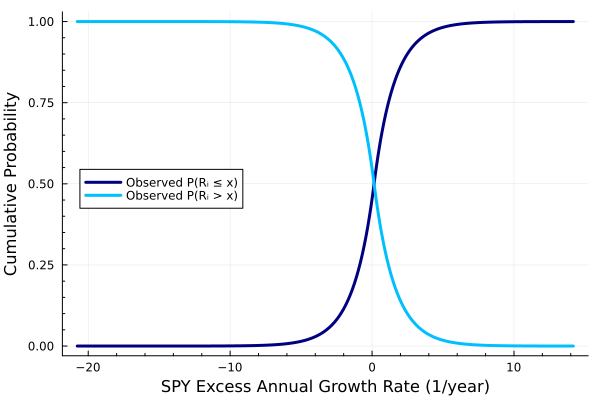

In [57]:
let

    # regions of return -
    number_of_samples = 1000;
    minimum_obs_growth = minimum(in_sample_dataset);
    maximum_obs_growth = maximum(in_sample_dataset);
    RA = range(minimum_obs_growth,stop = maximum_obs_growth, length = number_of_samples) |> collect;

    X = Array{Float64,2}(undef, number_of_samples,2);
    for i ∈ eachindex(RA)

        X[i,1] = RA[i];
        X[i,2] = cdf(d, RA[i]);
    end

    plot(X[:,1], X[:,2], lw=3, c=:navy, label="Observed P(Rᵢ ≤ x)", xminorticks=5, yminorticks=5)
    plot!(X[:,1], 1 .- X[:,2], lw=3, c=:deepskyblue1, label="Observed P(Rᵢ > x)", legend=:left)

    xlabel!("$(ticker) Excess Annual Growth Rate (1/year)", fontsize=18);
    ylabel!("Cumulative Probability", fontsize=18);
end

Next, we generate the percentile cutoffs that we use to establish the bounds that correspond to each category of return, i.e., `super bad` or `super good`, etc.

In [58]:
percentage_cutoff = range(0.0,stop=1.0,length=(number_of_states+1)) |> collect

21-element Vector{Float64}:
 0.0
 0.05
 0.1
 0.15
 0.2
 0.25
 0.3
 0.35
 0.4
 0.45
 0.5
 0.55
 0.6
 0.65
 0.7
 0.75
 0.8
 0.85
 0.9
 0.95
 1.0

Now that we have the cutoffs, compute the lower and upper bound for each potentiual category. To do this, we'll use the [quantile function](https://juliastats.org/Distributions.jl/stable/univariate/#Statistics.quantile-Tuple{UnivariateDistribution,%20Real}) exported by the [Distributions.jl package](https://github.com/JuliaStats/Distributions.jl). For a given `0 ≤ q ≤ 1`, `quantile(d, q)` is the smallest value `x`
for which `cdf(d, x) ≥ q`.

In [59]:
bounds = Array{Float64,2}(undef, number_of_states, 3)
for s ∈ states
    bounds[s,1] = quantile(d,percentage_cutoff[s])
    bounds[s,2] = quantile(d,percentage_cutoff[s+1])
    bounds[s,3] = s
end
bounds

20×3 Matrix{Float64}:
 -Inf        -3.21001    1.0
  -3.21001   -2.20071    2.0
  -2.20071   -1.6103     3.0
  -1.6103    -1.1914     4.0
  -1.1914    -0.86648    5.0
  -0.86648   -0.600998   6.0
  -0.600998  -0.376537   7.0
  -0.376537  -0.182099   8.0
  -0.182099  -0.010593   9.0
  -0.010593   0.142824  10.0
   0.142824   0.296242  11.0
   0.296242   0.467748  12.0
   0.467748   0.662186  13.0
   0.662186   0.886647  14.0
   0.886647   1.15213   15.0
   1.15213    1.47705   16.0
   1.47705    1.89595   17.0
   1.89595    2.48636   18.0
   2.48636    3.49566   19.0
   3.49566   Inf        20.0

Now that we have the category bounds, let's take the excess return data and determine which state an excess return observation corresponds to. For each sample in the `in_sample_dataset`:
* Classify the sample value into one of the possible categories. Let `state = 1` equal the worst return, and `state = number_of_states` equal the best return. Save these results in the `encoded_in_sample` array:

In [60]:
encoded_in_sample = Array{Int64,1}();
for i ∈ eachindex(in_sample_dataset)
    value = in_sample_dataset[i];

    class_index = 1;
    for s ∈ states
        if (bounds[s,1] ≤ value && value < bounds[s,2])
            class_index = s;
            break;
        end
    end
    push!(encoded_in_sample, class_index);
end
encoded_in_sample

2766-element Vector{Int64}:
  6
 14
 11
 10
 11
  4
 12
 18
  8
  7
  9
 12
  3
  ⋮
  7
 15
  5
  1
  2
 11
 17
 19
 14
  2
  2
  5

This cell can be used to check the density of each hidden state.

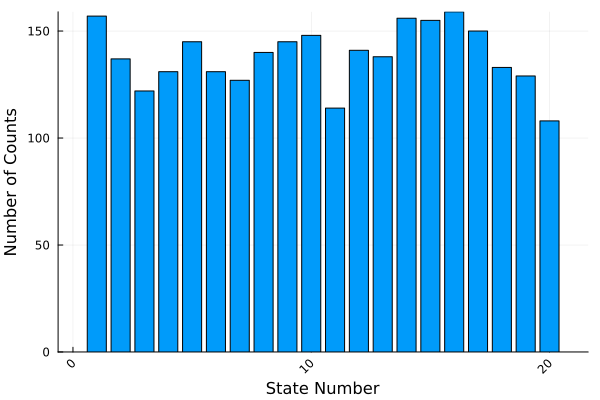

In [61]:
let
# Create a map of states to their counts
counts = countmap(encoded_in_sample);

# Sort the states by their frequency in descending order
ranked_states = sort(collect(counts), by=x->x[2], rev=true);

# Display the ranked list
# The output will be an array of pairs: (state => count)
ranked_states;

# Let's sort it by the state number (the key) for a cleaner plot.
sorted_by_state = sort(ranked_states, by = x -> x[1])

# Extract the states (keys) and counts (values) into separate arrays
states = [item[1] for item in sorted_by_state]
counts = [item[2] for item in sorted_by_state]

# Create the bar plot
bar(states, counts,
    legend=false,
    xlabel="State Number",
    ylabel="Number of Counts",
    xticks=0:10:200, # Adjust tick marks for readability
    xrotation=45,     # Rotate x-axis labels if they overlap
)

end

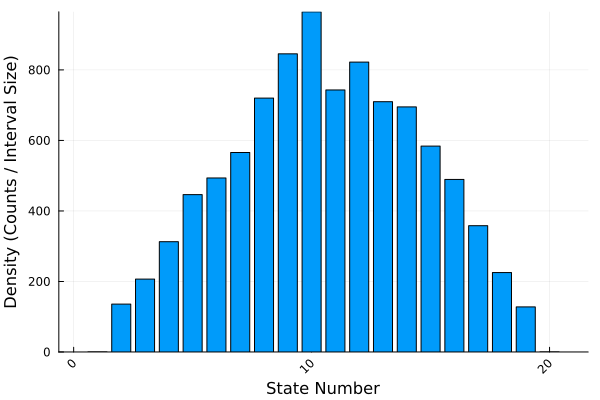

In [62]:
let
    # Create a map of states to their counts
    counts_map = countmap(encoded_in_sample);

    # Let's sort it by the state number (the key) for a cleaner plot.
    sorted_by_state = sort(collect(counts_map), by = x -> x[1])

    # Extract the states (keys) and counts (values) into separate arrays
    states = [item[1] for item in sorted_by_state]
    counts = [item[2] for item in sorted_by_state]

    # Calculate the interval size for each state from the 'bounds' array
    # This is the crucial step to account for non-uniform bin widths
    interval_sizes = [bounds[s, 2] - bounds[s, 1] for s in states]

    # Scale the counts by the interval size to get the density
    density = counts ./ interval_sizes

    # Create the bar plot using the calculated density
    bar(states, density,
        legend = false,
        xlabel = "State Number",
        ylabel = "Density (Counts / Interval Size)",
        xticks = 0:10:200, # Adjust tick marks for readability
        xrotation = 45,    # Rotate x-axis labels if they overlap
    )
    #println("$interval_sizes")
end

In [63]:
let
    # We will plot states 2 through 199, as state 1 and 200 have infinite interval sizes, which would make the plot's y-axis scale meaningless.
    # Define the range of states to plot
    middle_states = 2:199

    # Calculate the interval size for each of these middle states
    # This is the difference between the upper bound (column 2) and lower bound (column 1)
    interval_sizes_middle = [bounds[s, 2] - bounds[s, 1] for s in middle_states]

    # Create the bar plot
    bar(middle_states, interval_sizes_middle,
        legend = false,
        xlabel = "State Number",
        ylabel = "Interval Size",
        title = "Interval Size per State (Excluding States 1 and 200)",
        xticks = 0:10:200, # Adjust tick marks for readability
        xrotation = 45,    # Rotate x-axis labels if they overlap
    )
end


LoadError: BoundsError: attempt to access 20×3 Matrix{Float64} at index [21, 2]

In [64]:
counts = countmap(encoded_in_sample) |> argmax;

In the matrix $\mathbf{T}$ compute the `counts` for transition from state `i` to state `j`:

In [65]:
T = zeros(number_of_states, number_of_states)
number_insample = length(encoded_in_sample);
for i ∈ 2:number_insample
    start_index = encoded_in_sample[i-1];
    stop_index = encoded_in_sample[i];
    T[start_index,stop_index] += 1;
end
T

20×20 Matrix{Float64}:
 35.0  15.0   6.0  12.0   9.0   4.0  …   6.0   4.0   6.0   4.0   9.0  13.0
 19.0  16.0   9.0  12.0  10.0   4.0      5.0   9.0   7.0   6.0   8.0   5.0
 14.0   4.0  13.0   4.0   6.0   5.0      6.0   3.0   9.0  10.0  10.0   9.0
  9.0   9.0  13.0   7.0   6.0   9.0      7.0   4.0   7.0   4.0  12.0   1.0
 10.0   7.0  10.0   5.0   9.0  13.0      6.0  10.0  11.0   8.0   4.0   4.0
  6.0   7.0   7.0   9.0   9.0   8.0  …   7.0  11.0   4.0   6.0   2.0   3.0
  7.0   7.0   3.0   7.0   3.0  11.0     10.0  14.0   6.0   3.0   2.0   3.0
  6.0   7.0   7.0   6.0   7.0   3.0     11.0  10.0   2.0   6.0   0.0   3.0
  6.0   7.0   9.0   8.0  12.0   6.0     10.0   2.0   9.0   3.0   2.0   1.0
  2.0  10.0   4.0   5.0  13.0   8.0      6.0  10.0   3.0   6.0   3.0   3.0
  1.0   3.0   2.0   8.0   6.0   7.0  …   3.0   7.0   5.0   4.0   5.0   5.0
  4.0   6.0   6.0   3.0   5.0   8.0      8.0  11.0  12.0   7.0   3.0   3.0
  4.0   6.0   8.0   7.0   8.0   4.0      8.0   6.0   4.0   6.0   4.0   3.0
  

From the `counts` matrix $\mathbf{T}$, compute the transtion probability matrix $\hat{\mathbf{T}}$:

In [66]:
T̂ = zeros(number_of_states, number_of_states)
for row ∈ states
    Z = sum(T[row,:]);
    for col ∈ states
        T̂[row,col] = (1/Z)*T[row,col]
    end
end
T̂

20×20 Matrix{Float64}:
 0.22293     0.0955414  0.0382166  …  0.0254777  0.0573248  0.0828025
 0.138686    0.116788   0.0656934     0.0437956  0.0583942  0.0364964
 0.114754    0.0327869  0.106557      0.0819672  0.0819672  0.0737705
 0.0687023   0.0687023  0.0992366     0.0305344  0.0916031  0.00763359
 0.0694444   0.0486111  0.0694444     0.0555556  0.0277778  0.0277778
 0.0458015   0.0534351  0.0534351  …  0.0458015  0.0152672  0.0229008
 0.0551181   0.0551181  0.023622      0.023622   0.015748   0.023622
 0.0428571   0.05       0.05          0.0428571  0.0        0.0214286
 0.0413793   0.0482759  0.062069      0.0206897  0.0137931  0.00689655
 0.0135135   0.0675676  0.027027      0.0405405  0.0202703  0.0202703
 0.00877193  0.0263158  0.0175439  …  0.0350877  0.0438596  0.0438596
 0.0283688   0.0425532  0.0425532     0.0496454  0.0212766  0.0212766
 0.0289855   0.0434783  0.057971      0.0434783  0.0289855  0.0217391
 0.0128205   0.0641026  0.0320513     0.0192308  0.0512821  0.0256

## Task 2: In-Sample Analysis of the Standard HMM
To do the simulation, we first build a [`MyHiddenMarkovModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/markov/#VLQuantitativeFinancePackage.MyHiddenMarkovModel), which holds the data for our Markov model. We use a [`build(...)` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/markov/#VLQuantitativeFinancePackage.build-Tuple{Type{MyHiddenMarkovModel},%20NamedTuple}), which takes information about the `states,` the estimated transition matrix $\hat{\mathbf{T}}$, and the emission matrix $\mathbf{E}$ and returns a [`MyHiddenMarkovModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/markov/#VLQuantitativeFinancePackage.MyHiddenMarkovModel), which we save in the `model` variable.

In [67]:
model = build(MyHiddenMarkovModel, (
    states = states,
    T = T̂,
    E = E
));

### Generate the stationary distribution from the estimated $\hat{\mathbf{T}}$ matrix
Generate the stationary distribution for the estimated transition matrix $\hat{\mathbf{T}}$ and use it to construct a [Categorical distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Categorical) representing the stationary distrubution, save the [Categorical distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Categorical) in the `π̄`-variable:

In [68]:
power_value = 50;
π̄ = (T̂^power_value) |> tmp -> Categorical(tmp[1,:]); # compute the stationary distribution (approx value is ok)

### Implement the `MARKOV-SIMULATION` to generate hypothetical return sequences
Generate 'number_of_paths' example sequences, each containing 'number_of_steps' days. These variables determine the length and number of our hypothetical return sequences. Assume each path starts from a draw from the stationary distribution `π̄.`
* Save the simulated return sequences in the `archive::Array{Int64,2}(undef, number_of_steps, number_of_paths)` array, where the `row` index corresponds to a path, and the `col` index corresponds to a day.
* We have implemented some shortcut logic to speed up the implementation. To evaluate the Markov model for a `number_of_steps,` issue the command `model(start_state, number_of_steps).` This will compute a chain with `number_of_steps` starting as `start_state` and return the simulated sequence as an `array.`

In [69]:
number_of_steps = maximum_number_trading_days;
encoded_archive = Array{Int64,2}(undef, number_of_steps, number_of_paths);
for i ∈ 1:number_of_paths
    start_state = rand(π̄);
    tmp = model(start_state, number_of_steps)
    for j ∈ 1:number_of_steps
        encoded_archive[j,i] = tmp[j]
    end
end
encoded_archive

2767×100 Matrix{Int64}:
  5  19  18  19   5  13  18  11   7  …   8  11  17   9   9  18   6   6  18
 10   2  20  16  12  11  15   4  14      4   7  19   9   3  15   6  16  11
 12  19   8   8   9   4   7  11  15      9  15  13   7   1   3   7  11  14
 18  18  15  15   7   1   7   7   4     11  13   9   3  12  19  11  10  13
  5  17  17  16  16   2  11   9  14     13   4   5  18  13   8  10  12   9
 20  19   6  15  14  19  10   7   4  …  12  13   8   8  12  15   7  15   5
 18   1   5  15  20  18  15   7  19      9  16   9  13   5  12   7  11  15
 18   1  12   7  17  12  18   7   2      5  15  11   8  17   9   6   9   6
 10  15   9  18  14  13  20   7   5      6  16  16   4   8  11   2   4   6
  9  13  15   8  14   9  10  15   3     18  11  14  19  10  14   2   5   3
  4  16   3   7   3   5   9  15  12  …  17   7   2  19  15   5  19   5  15
 10  18  18   4  17   6   3  12   7     15   8  20  18  10  16  16   5  13
  6  14  15   1   7  12   8   4  13      8  15   5  16   5  10  14   1  15
 

In [70]:
actual_sample_bounds = copy(bounds);
actual_sample_bounds[1,1] = minimum(in_sample_dataset);
actual_sample_bounds[end,2] = maximum(in_sample_dataset)
actual_sample_bounds

20×3 Matrix{Float64}:
 -20.7722    -3.21001    1.0
  -3.21001   -2.20071    2.0
  -2.20071   -1.6103     3.0
  -1.6103    -1.1914     4.0
  -1.1914    -0.86648    5.0
  -0.86648   -0.600998   6.0
  -0.600998  -0.376537   7.0
  -0.376537  -0.182099   8.0
  -0.182099  -0.010593   9.0
  -0.010593   0.142824  10.0
   0.142824   0.296242  11.0
   0.296242   0.467748  12.0
   0.467748   0.662186  13.0
   0.662186   0.886647  14.0
   0.886647   1.15213   15.0
   1.15213    1.47705   16.0
   1.47705    1.89595   17.0
   1.89595    2.48636   18.0
   2.48636    3.49566   19.0
   3.49566   14.1804    20.0

### Decode operation
To turn the state $s\in\mathcal{S}$ back into an excess return value, we need to __decode__ the state. To do this, let's construct a [Normal distribution](https://en.wikipedia.org/wiki/Normal_distribution) describing the observed return values associated with each state in the `encoded_in_sample` dataset.
* We collect the observed excess return samples associated with a particular state $s$, store them in a `tmp` array, and use [Maximum Likelihood Estimation](https://en.wikipedia.org/wiki/Maximum_likelihood_estimation) to estimate a [Normal distribution exported from the Distributions.jl package](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Normal)

In [71]:
decode_distribution_model = Dict{Int,Normal}()
for s ∈ states

    # what indexes correspond to state s
    index_collection_state_s = findall(x-> x == s, encoded_in_sample);
    tmp = Array{Float64,1}();
    for i ∈ index_collection_state_s
        decoded_value = Rᵢ[i];
        push!(tmp, decoded_value);
    end
    decode_distribution_model[s] = fit_mle(Normal,tmp);
end
decode_distribution_model;

Then, generate a random value for the excess return by sampling the appropriate [Normal distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Normal). We develop `number_of_paths` trajectories, each containing `number_of_steps` values. We store these values in the `decoded_archive` variable:

In [72]:
in_sample_decoded_archive = Array{Float64,2}(undef, number_of_steps, number_of_paths);
for i ∈ 1:number_of_paths
    for j ∈ 1:number_of_steps
        s = encoded_archive[j,i];
        in_sample_decoded_archive[j,i] =  decode_distribution_model[s] |> d -> rand(d)
    end
end
in_sample_decoded_archive # actual excess growth value

2767×100 Matrix{Float64}:
 -0.940795    3.03712     2.34028    …  -0.794675   -0.7423      2.05653
  0.0472967  -2.12354     5.88871       -0.629623    1.33875     0.154917
  0.450527    3.43838    -0.253187      -0.455796    0.223242    0.808811
  2.21356     2.11003     1.04595        0.209313    0.0287762   0.542215
 -0.977998    1.90772     1.57176        0.0996968   0.369022   -0.066913
  1.00779     3.2158     -0.682779   …  -0.602466    1.035      -1.12161
  2.08951    -9.49577    -1.02967       -0.444557    0.186484    0.910139
  1.93916    -9.78092     0.336702      -0.669504   -0.0707556  -0.785598
  0.0933637   0.986916   -0.0437383     -2.72901    -1.35835    -0.792024
 -0.0633917   0.548035    1.01146       -2.62579    -1.05603    -2.02634
 -1.38872     1.41844    -1.83203    …   3.4961     -1.00314     0.993292
  0.0715059   2.10097     2.28864        1.29621    -0.96708     0.59798
 -0.741411    0.664778    1.05324        0.749006   -2.93529     1.04146
  ⋮              

### Visualize an example in-sample return trajectory
`Unhide` the code block to see how we plotted the observed (red) and simulated (blue) excess growth rate values for a randomly selected sample model generated sample path.

`Unhide` the code block below to see how we plotted the observed and simulated excess annual growth rate distribution for the in-sample data.

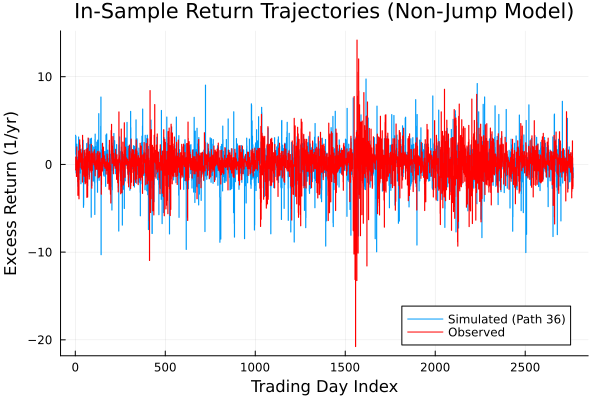

In [73]:
let
    # Select a random path to plot, just like in your working example
    index_to_plot = rand(1:number_of_paths)

    # Plot the SIMULATED data first, creating the plot
    plot(in_sample_decoded_archive[:, index_to_plot], linetype=:steppost, label="Simulated (Path $(index_to_plot))")

    # Add the OBSERVED data to the plot, slicing it to match the simulation length
    plot!(in_sample_dataset[1:(number_of_steps - 1)], linetype=:steppost, c=:red, label="Observed")
    
    # Add labels and a title
    xlabel!("Trading Day Index")
    ylabel!("Excess Return (1/yr)")
    title!("In-Sample Return Trajectories (Non-Jump Model)")
end

### Check: Are the Simulated and observed in-sample distributions the same?
If our Markov model is correct, then the observed excess growth rate distribution and the excess growth distribution calculated by our model should look like they are drawn from the same distribution. To check this hypothesis, use [the ApproximateTwoSampleKSTest exported by the HypothesisTests.jl package](https://github.com/JuliaStats/HypothesisTests.jl) with the hypotheses:
* `H0:null hypothesis` is that `x` and `y` are drawn from the same distribution against the `H1:alternative hypothesis` that `x` and `y` come from different distributions.

Let's run [the ApproximateTwoSampleKSTest function](https://github.com/JuliaStats/HypothesisTests.jl) on a single (randomly selected) example trajectory to see what happens (most of the time, we fail to reject `H0`, i.e., the test suggests `x` and `y` are from the same distribution):

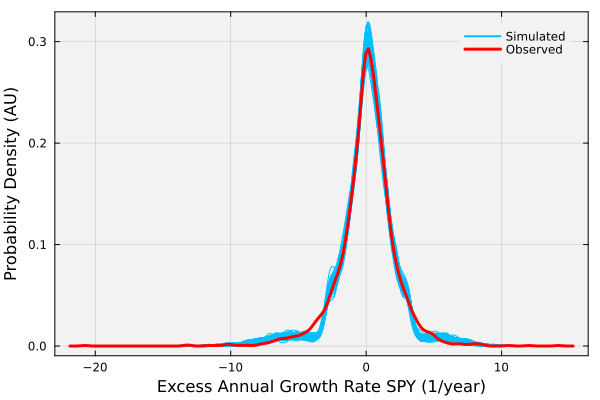

In [74]:
let
    q = plot();
    density!(in_sample_decoded_archive[:,1], lw=2, c=:deepskyblue1, label="Simulated",
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent)
    for i ∈ 2:number_of_paths
        density!(in_sample_decoded_archive[:,i], lw=1, c=:deepskyblue1, label="")
    end
    density!(in_sample_dataset, c=:red, lw=3, label="Observed")
    xlabel!("Excess Annual Growth Rate $(ticker) (1/year)", fontsize=18)
    ylabel!("Probability Density (AU)", fontsize=18)
    current()
end

In [75]:
ApproximateTwoSampleKSTest(in_sample_dataset,in_sample_decoded_archive[:,rand(1:number_of_paths)])

Approximate two sample Kolmogorov-Smirnov test
----------------------------------------------
Population details:
    parameter of interest:   Supremum of CDF differences
    value under h_0:         0.0
    point estimate:          0.0188145

Test summary:
    outcome with 95% confidence: fail to reject h_0
    two-sided p-value:           0.7117

Details:
    number of observations:   [2766,2767]
    KS-statistic:              0.6997492499660123


However, we have `number_of_paths` example trajectories (not just one), so let's do the same test on each sample and compute an overall expected score. Specify a `pvalue_cutoff` value to check against. If the test returns `pvalue > pvalue_cutoff,` then we fail to reject `H0:null hypothesis`, i.e., `x` and `y` appear to be drawn from the same distribution.

In [76]:
let
    pvalue_cutoff = 0.05; # cutoff
    pass_counter = 0;
    for i ∈ 1:number_of_paths
        test_value = ApproximateTwoSampleKSTest(in_sample_dataset,in_sample_decoded_archive[:,i]) |> pvalue
        if (test_value > pvalue_cutoff)
            pass_counter += 1 # we pass (fail to reject) x and y are from the same distribution
        end
    end
    println("Pass percentage: $((pass_counter/number_of_paths)*100)%")
end

Pass percentage: 100.0%


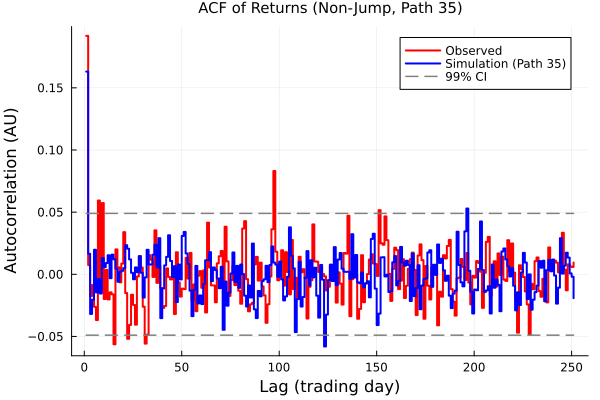

In [77]:
let
    random_index = rand(1:number_of_paths)
    simulated_path = in_sample_decoded_archive[:, random_index]
    plot_acf_comparison(Rᵢ, simulated_path, "ACF of Returns (Non-Jump, Path $(random_index))", random_index)
end

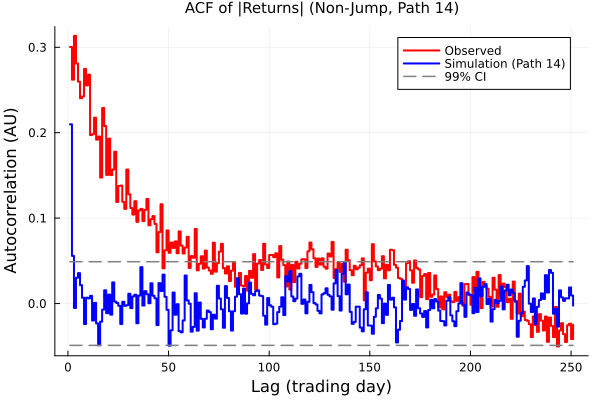

In [78]:
let
    random_index = rand(1:number_of_paths)
    simulated_path = in_sample_decoded_archive[:, random_index]
    plot_acf_comparison(Rᵢ, simulated_path, "ACF of |Returns| (Non-Jump, Path $(random_index))", random_index, is_absolute=true)
end

### Conclusion from the Non-Jump Model Analysis

The autocorrelation plots reveal a key insight:
* **Success:** The standard HMM successfully replicates the lack of significant autocorrelation in raw returns, consistent with the efficient market hypothesis.
* **Failure:** The model completely fails to reproduce the strong, persistent autocorrelation in **absolute returns**. This means the simple HMM **cannot capture volatility clustering**, a critical stylized fact of financial markets.

This failure motivates the need for a more sophisticated model, which we explore in Task 4.

## Task 3: Improving the Model with Jumps

Having established the primary weakness of the standard HMM, we now test if the modified model that includes price jumps can address this shortcoming. We will run the same autocorrelation analysis on the jump model's output to directly compare its ability to generate realistic volatility clustering.

In this task, we test if a modified Markov model that includes price jumps can address the shortcomings of the simple HMM. We will run the same autocorrelation analysis on the jump model's output to directly compare its ability to generate realistic volatility clustering.
Suppose every so often, instead of transitioning to the next state by sampling the transition matrix, we jump to a __tail state__ of the cumulative distribution. We then stay in one of the tail states for a random number of steps, governed by a [Possion distribution](https://en.wikipedia.org/wiki/Poisson_distribution).



Let us first estimate `λ::Int64` from empirical data

Then, let us estimate `ϵ::Float64` from empirical data

In [92]:
# --- SET THIS TO true TO RUN THE SEARCH, OR false TO USE MANUAL VALUES ---
run_grid_search = true;

# This variable will hold the final parameters, either from the search or set manually
final_params = (ϵ=0.0, λ=0.0);

if run_grid_search
    println("Starting grid search to find optimal ϵ and λ...")
    
    # 1. Define our TWO target signatures
    target_acf = autocor(abs.(Rᵢ), 1:252);
    target_kurtosis = kurtosis(Rᵢ);

    # 2. Define the grid of parameters to search over
    epsilon_grid = 0.00001:0.00001:0.0001;
    lambda_grid = 1.0:1.0:100.0;
    kurtosis_penalty_weight = 0.20; # A higher weight means the search will prioritize matching the tails.

    # Store intermediate search results here
    best_params_from_search = (ϵ=0.0, λ=0.0);
    lowest_error = Inf;
    number_of_simulation_paths = 100;

    # 3. Start the search
    p = Progress(length(epsilon_grid) * length(lambda_grid), "Searching...")
    for ϵ_val in epsilon_grid
        for λ_val in lambda_grid
            temp_model = build(MyHiddenMarkovModelWithJumps, (states=states, T=T̂, E=E, ϵ=ϵ_val, λ=λ_val));
            simulated_paths = [_simulate(temp_model, rand(π̄), number_of_steps) for _ in 1:number_of_simulation_paths];
            decoded_paths = [[rand(decode_distribution_model[s]) for s in path] for path in simulated_paths];

            # Calculate combined error
            avg_sim_acf = mean([autocor(abs.(path), 1:252) for path in decoded_paths]);
            acf_error = sum((avg_sim_acf .- target_acf).^2);
            avg_sim_kurtosis = mean([kurtosis(path) for path in decoded_paths]);
            kurtosis_error = (avg_sim_kurtosis - target_kurtosis)^2;
            current_error = acf_error + (kurtosis_penalty_weight * kurtosis_error);

            if current_error < lowest_error
                lowest_error = current_error;
                best_params_from_search = (ϵ=ϵ_val, λ=λ_val);
            end
            next!(p)
        end
    end
    
    # Use the parameters found by the search
    final_params = best_params_from_search;
    println("Optimal parameters found via multi-objective search:")

else
    # If not running the search, use these pre-defined manual values
    println("Skipping grid search. Using manual parameters.")
    manual_epsilon = 0.00005;
    manual_lambda = 77.0;
    final_params = (ϵ=manual_epsilon, λ=manual_lambda);
end

# Extract the final values to be used in the next cells
ϵ = final_params.ϵ;
λ = final_params.λ;

println("--------------------------------------------------")
println("Using final parameters: ϵ = $(ϵ), λ = $(λ)")

Searching...   0%|▏                                      |  ETA: 0:01:08

Starting grid search to find optimal ϵ and λ...


Searching... 100%|███████████████████████████████████████| Time: 0:00:30


Optimal parameters found via multi-objective search:
--------------------------------------------------
Using final parameters: ϵ = 8.0e-5, λ = 88.0


To explore this idea, we built [a `MyHiddenMarkovModelWithJumps` instance](src/Types.jl), which holds the same data as the non-jump model. However, we now have two new parameters: the `ϵ::Float64` parameter controls the frequency with which we observe jumps, and the `λ::Int64` parameter is the mean number of events that occur in a given time frame.

We save this model in the `jump_model::MyHiddenMarkovModelWithJumps` variable

In [93]:
jump_model = let

    model = build(MyHiddenMarkovModelWithJumps, (
        states = states,
        T = T̂,
        E = E,
        ϵ = ϵ, # fraction of steps that we have a jump event
        λ = λ, # mean number of jump events
    ));

    model;
end;

__Sample__: Next, we sample the `jump_model::MyHiddenMarkovModelWithJumps` model. Sampling the model results in the `encoded_archive_with_jumps::Array{Float64,2}` array, which holds sample paths (alternative futures) on the columns and time steps on the rows.

In [94]:
encoded_archive_with_jumps = let
    encoded_archive = Array{Int64,2}(undef, number_of_steps, number_of_paths);
    for i ∈ 1:number_of_paths
        start_state = rand(π̄);

        @show i

        tmp = jump_model(start_state, number_of_steps)
        for j ∈ 1:number_of_steps
            encoded_archive[j,i] = tmp[j]
        end
    end
    encoded_archive
end;

i = 1
i = 2
i = 3
i = 4
i = 5
i = 6
i = 7
i = 8
i = 9
i = 10
i = 11
i = 12
i = 13
i = 14
i = 15
i = 16
i = 17
i = 18
i = 19
i = 20
i = 21
i = 22
i = 23
i = 24
i = 25
i = 26
i = 27
i = 28
i = 29
i = 30
i = 31
i = 32
i = 33
i = 34
i = 35
i = 36
i = 37
i = 38
i = 39
i = 40
i = 41
i = 42
i = 43
i = 44
i = 45
i = 46
i = 47
i = 48
i = 49
i = 50
i = 51
i = 52
i = 53
i = 54
i = 55
i = 56
i = 57
i = 58
i = 59
i = 60
i = 61
i = 62
i = 63
i = 64
i = 65
i = 66
i = 67
i = 68
i = 69
i = 70
i = 71
i = 72
i = 73
i = 74
i = 75
i = 76
i = 77
i = 78
i = 79
i = 80
i = 81
i = 82
i = 83
i = 84
i = 85
i = 86
i = 87
i = 88
i = 89
i = 90
i = 91
i = 92
i = 93
i = 94
i = 95
i = 96
i = 97
i = 98
i = 99
i = 100


__Decode__: We then decode the encoded states and save the decoded values in the `in_sample_decoded_archive_with_jumps::Array{Float64,2}` array. Each row is a return value at the time step, while each column is a sample path, i.e., an alternative universe in which our process is running

In [95]:
in_sample_decoded_archive_with_jumps = let
    in_sample_decoded_archive = Array{Float64,2}(undef, number_of_steps, number_of_paths);
    for i ∈ 1:number_of_paths
        for j ∈ 1:number_of_steps
            s = encoded_archive_with_jumps[j,i];
            in_sample_decoded_archive[j,i] =  decode_distribution_model[s] |> d -> rand(d)
        end
    end
    in_sample_decoded_archive # actual excess growth value
end;

In [96]:
in_sample_decoded_archive_with_jumps

2767×100 Matrix{Float64}:
  0.215207  -1.43971     1.71517    …  -0.271856   -1.22599     0.801674
  0.44916   -0.651492    6.64163       -0.520531    0.100989   -0.4429
 -1.52839    2.20883     6.53698        1.04913     0.0805672  -0.0797991
  1.00595    1.54054     1.68439       -0.155044    0.580492    0.79901
  6.0918    -0.660664    0.221792       0.501283   -0.220871    2.85115
 -1.00698    0.879345    0.382451   …  -1.90703     1.1839     -0.298188
  0.339841  -0.128769    1.0504         3.08893    -1.3674     -0.556572
  0.220383  -2.0134      0.950604       4.48697    -8.49167     2.18374
 -0.100985  -0.987707    1.05861        0.0365823  -0.557571    3.4591
 -0.522254  -0.373728    0.36728       -0.97572     1.04137    -0.936178
  9.50011   -1.73768    -0.445161   …  -1.43603     0.59762    -2.48066
  3.64787    0.930269    0.448609       3.18965    -0.966739   -2.5173
  0.688726   0.764295    1.76072        3.2998      2.49369     1.01432
  ⋮                                

`Unhide` the code block below to see how we plotted the observed and simulated excess annual growth rate distribution for the in-sample data. These simulated returns are generated using the jump model.

### Visualize an example in-sample jump return trajectory
`Unhide` the code block to see how we plotted the observed (red) and simulated (blue) excess growth rate values for a randomly selected sample model generated sample path.

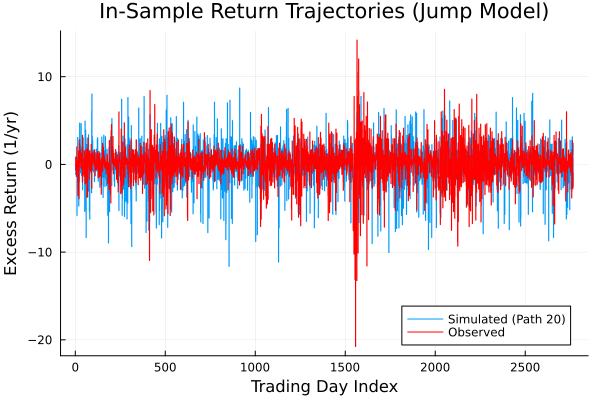

In [97]:
let
    # Select a random path to plot, just like in your working example
    index_to_plot = 20 #rand(1:number_of_paths)

    # Plot the SIMULATED data first, creating the plot
    plot(in_sample_decoded_archive_with_jumps[:,index_to_plot], linetype=:steppost, label="Simulated (Path $(index_to_plot))")

    # Add the OBSERVED data to the plot, slicing it to match the simulation length
    plot!(in_sample_dataset[1:(number_of_steps - 1)], linetype=:steppost, c=:red, label="Observed")
    
    # Add labels and a title
    xlabel!("Trading Day Index")
    ylabel!("Excess Return (1/yr)")
    title!("In-Sample Return Trajectories (Jump Model)")
end

### Check: Are the predicted jump model returns and observed in-sample distributions the same?
If our jump Markov model is correct, then the observed excess growth rate distribution and the excess growth distribution calculated by our jump model should look like they are drawn from the same distribution. To check this hypothesis, use [the ApproximateTwoSampleKSTest exported by the HypothesisTests.jl package](https://github.com/JuliaStats/HypothesisTests.jl) with the hypotheses:
* `H0:null hypothesis` is that `x` and `y` are drawn from the same distribution against the `H1:alternative hypothesis` that `x` and `y` come from different distributions.

Let's run [the ApproximateTwoSampleKSTest function](https://github.com/JuliaStats/HypothesisTests.jl) on a single (randomly selected) example trajectory to see what happens (most of the time, we fail to reject `H0`, i.e., the test suggests `x` and `y` are from the same distribution):

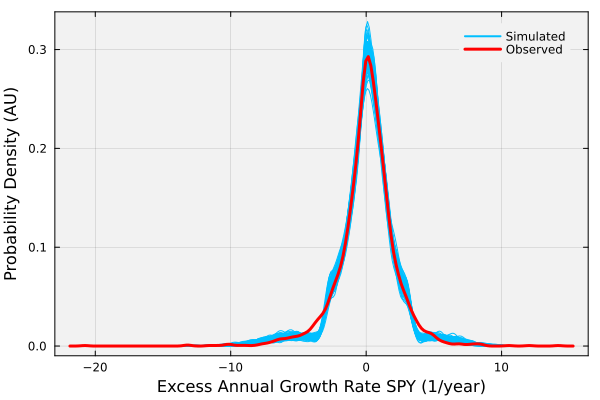

In [98]:
let
    q = plot();
    density!(in_sample_decoded_archive_with_jumps[:,1], lw=2, c=:deepskyblue1, label="Simulated",
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent)
    for i ∈ 2:number_of_paths
        density!(in_sample_decoded_archive_with_jumps[:,i], lw=1, c=:deepskyblue1, label="")
    end
    density!(in_sample_dataset, c=:red, lw=3, label="Observed")
    xlabel!("Excess Annual Growth Rate $(ticker) (1/year)", fontsize=18)
    ylabel!("Probability Density (AU)", fontsize=18)
    current()

    # # Save the figure
    # savefig(joinpath(_PATH_TO_FIGURES, "Fig-$(ticker)-ExcessGrowthRate-Probability-Density-HMM.svg"));

end


In [99]:
let
    pvalue_cutoff = 0.05; # 95% cutoff
    pass_counter = 0;
    for i ∈ 1:number_of_paths
        test_value = ApproximateTwoSampleKSTest(in_sample_dataset,in_sample_decoded_archive_with_jumps[:,i]) |> pvalue
        if (test_value > pvalue_cutoff)
            pass_counter += 1 # we pass (fail to reject) x and y are from the same distribution
        end
    end
    println("Pass percentage: $((pass_counter/number_of_paths)*100)%")
end

Pass percentage: 100.0%


### Stylized facts for in-sample dataset
This task compares the stylized facts for the observed insample and simulated excess growth datasets. In particular, we'll look at two stylized facts, namely, the autocorrelation of the excess growth rate and the volatility clustering, i.e., the autocorrelation of the absolute value of the excess growth rate.

#### Lack of Autocorrelation of Returns

First, we test a key stylized fact derived from the [random walk hypothesis](https://en.wikipedia.org/wiki/Random_walk_hypothesis): the autocorrelation of raw returns should be statistically insignificant for all lags. A model that successfully captures market behavior should be able to reproduce this lack of linear predictability.

##### Summary of Findings
* The plot below compares the autocorrelation of the observed **in-sample** returns (`Rᵢ`) with a randomly selected simulation path.
* As expected, both the real-world data (red) and the simulated data (blue) show near-zero autocorrelation that lies mostly within the 95% confidence interval.
* This confirms that our model successfully captures this feature of the data.

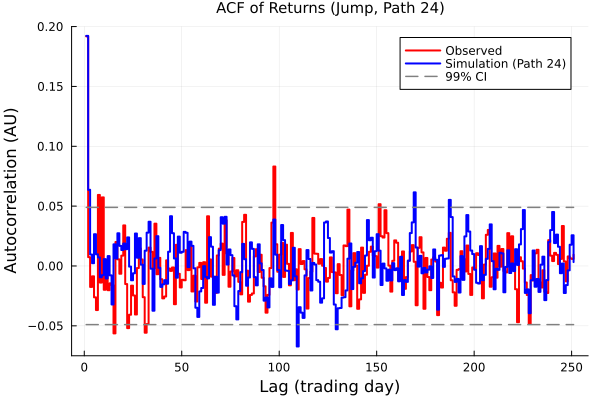

In [100]:
let
    random_index = rand(1:number_of_paths)
    simulated_path_jumps = in_sample_decoded_archive_with_jumps[:, random_index]
    plot_acf_comparison(Rᵢ, simulated_path_jumps, "ACF of Returns (Jump, Path $(random_index))", random_index)
end

#### Volatility Clustering

Next, we examine a more complex stylized fact: **volatility clustering**. This is the tendency for large market movements (of either sign) to be followed by more large movements, and for calm periods to be followed by more calm periods. We test for this by analyzing the autocorrelation of the **absolute value** of the returns.

##### Summary of Findings
* The observed **in-sample** data (red line) shows positive and persistent autocorrelation in its absolute returns. This is the classic signature of volatility clustering.
* The plot below shows that the **Jump Markov model** (blue line) successfully replicates this pattern, demonstrating a significant improvement over a simple HMM. This confirms the jump component is crucial for capturing this key market dynamic.

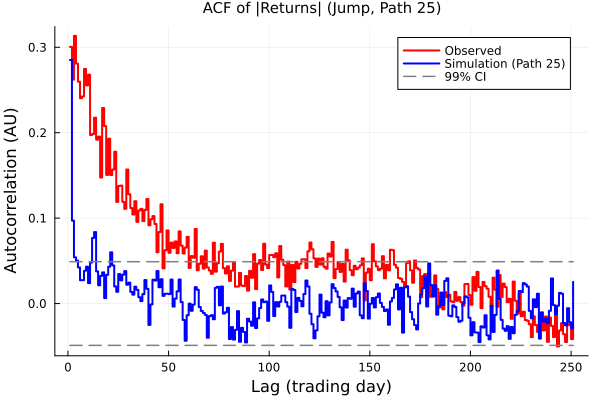

In [113]:
let
    random_index = rand(1:number_of_paths)
    simulated_path_jumps = in_sample_decoded_archive_with_jumps[:, random_index]
    plot_acf_comparison(Rᵢ, simulated_path_jumps, "ACF of |Returns| (Jump, Path $(random_index))", random_index, is_absolute=true)
end

## Task 4: Save the Model Artifacts
We'll use the hidden Markov Model (HMM) we developed here. Let's save the model to disk to save some time later on. Use the [save(...) method exported by the JLD2.jl package](https://github.com/JuliaIO/JLD2.jl.git) to write a [model file in HDF5 binary format](https://en.wikipedia.org/wiki/Hierarchical_Data_Format). First, we specify a `path` in the `path_to_save_file` variable:

In [102]:
path_to_save_file = joinpath(_PATH_TO_DATA,"HMM-WJ-$(ticker)-daily-aggregate.jld2");

Then we write an [`HDF5 binary file`](https://en.wikipedia.org/wiki/Hierarchical_Data_Format) holding our data to the location specified by `path_to_save_file.` We use the [save(...) function exported by the JLD2.jl package to write a binary save file](https://github.com/JuliaIO/JLD2.jl.git) (later we'll use to the `load(...)` function to reload this data):

In [103]:
save(path_to_save_file, Dict("model"=>model, "jump_model" => jump_model,
        "decode"=>decode_distribution_model, "stationary"=>π̄,
        "insampledataset"=>in_sample_dataset, "encoded_archive" => encoded_archive, "encoded_archive_with_jumps" => encoded_archive_with_jumps,
        "in_sample_decoded_archive_with_jumps" => in_sample_decoded_archive_with_jumps,
        "in_sample_decoded_archive" => in_sample_decoded_archive));

## Overall Conclusion

This analysis successfully demonstrated both the capabilities and the limitations of Hidden Markov Models for modeling financial returns.

The key findings are:
1.  **Data Characterization:** The underlying distribution of daily excess returns is characterized by "fat tails," which are better modeled by a **Student's t-distribution** than a Laplace or Normal distribution.

2.  **Standard HMM Performance:** A standard HMM is effective at capturing the basic return distribution and the lack of autocorrelation in raw returns. However, it **fundamentally fails** to reproduce the volatility clustering observed in the market.

3.  **Jump Model Superiority:** By introducing a mechanism for jumps, the modified HMM is able to successfully replicate volatility clustering. This confirms that **the HMM with jumps is a demonstrably superior model** for capturing the essential stylized facts of financial returns.

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance.  Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. You should decide solely based on your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.